In [42]:
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.patheffects as path_effects
import sunpy
import sunpy.map
import dkist 
import dask.array as da
import h5py
from astropy.time import Time
from astropy.io import ascii, fits
from astropy.wcs import WCS
from astropy.visualization import (ImageNormalize, 
                    SqrtStretch, AsinhStretch)
from sunpy.coordinates import propagate_with_solar_surface
import astropy.units as u
from ndcube import NDCube
from sunkit_image import enhance
from glob import glob 
from astropy.coordinates import SkyCoord

In [22]:
eui_files = sorted(glob("/cluster/home/zhuyin/Solar/DKIST_SolO_Fibril/data/pid_1_123_aux/HRI/coalign_step_boxcar/*.fits"))
eui_map = sunpy.map.Map(eui_files[181],sequence=False,memmap=True)

Txshift_hri, Tyshift_hri = (1.66986 + 2.49223)*u.arcsec,(7.60204 - 2.76366 - 1.0 )*u.arcsec
eui_map = eui_map.shift_reference_coord(Txshift_hri,Tyshift_hri)
eui_map.meta["rsun_ref"] = 695700000 + 4.7e6
eui_map = eui_map.submap((200,200)*u.pix, top_right=(1600,1600)*u.pix)

In [23]:
eui_map_enhance = enhance.wow(eui_map, bilateral=1, denoise_coefficients=[5,3], h=0.99)

In [27]:
dkist_vbi_target_header = fits.getheader("../../data/pid_1_123_aux/plot_ready/dkist_target_wcs_header_before_crop.fits",
                                        ignore_missing_simple=True)

dkist_vbi_target_data = np.zeros((4096,4096))

dkist_vbi_target_cube = NDCube(dkist_vbi_target_data,WCS(dkist_vbi_target_header, naxis=2))
dkist_vbi_target_cube_crop = dkist_vbi_target_cube[128:-128,128:-128]
dkist_vbi_target_cube_crop_rebin = dkist_vbi_target_cube_crop.rebin((64,64))

Set MJD-BEG to 59876.791095 from DATE-BEG.
Set MJD-AVG to 59876.791095 from DATE-AVG.
Set MJD-END to 59876.791095 from DATE-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    20.706700 from OBSGEO-[XYZ].
Set OBSGEO-H to     3063.997 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [39]:
def get_cube_edge_coords(cube, step=1):
    ny, nx = cube.data.shape
    y = np.arange(0, ny, step, )
    x = np.arange(0, nx, step)
    
    coords_bottom = cube.wcs.pixel_to_world(x, np.zeros(len(x)))
    coords_right = cube.wcs.pixel_to_world(np.ones(len(y))*(nx-1), y)
    coords_top = cube.wcs.pixel_to_world(np.flip(x), np.ones(len(x))*(ny-1))
    coords_left = cube.wcs.pixel_to_world(np.zeros(len(y)), np.flip(y))

    return SkyCoord((coords_bottom, coords_right, coords_top, coords_left))

In [40]:
vbi_b_edge_coords = get_cube_edge_coords(dkist_vbi_target_cube_crop_rebin, step=1)

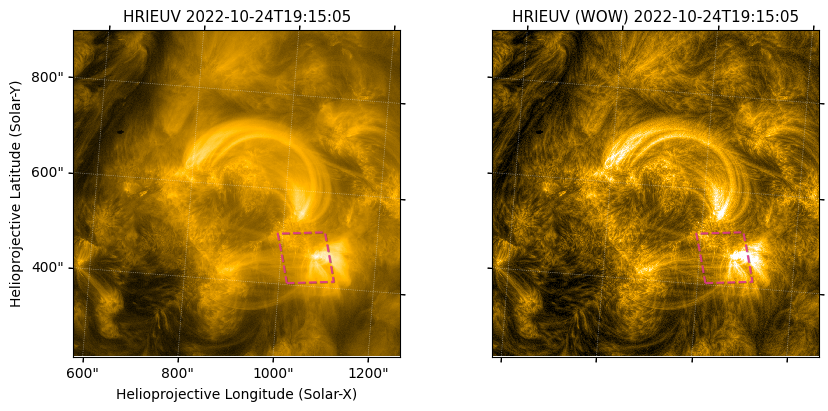

In [45]:
fig = plt.figure(figsize=(9,4), layout="constrained")

ax1 = fig.add_subplot(121, projection=eui_map.wcs)
im1 = eui_map.plot(axes=ax1, title=None, interpolation="none")
ax1.set_title("HRIEUV {}".format(eui_map.date.strftime("%Y-%m-%dT%H:%M:%S")), fontsize=11)

ax2 = fig.add_subplot(122, projection=eui_map_enhance.wcs)
im2 = eui_map_enhance.plot(axes=ax2, title=None,
                           norm=ImageNormalize(vmin=np.nanpercentile(eui_map_enhance.data, 0.2),
                           vmax=np.nanpercentile(eui_map_enhance.data, 99.8)), interpolation="none")
ax2.set_title("HRIEUV (WOW) {}".format(eui_map_enhance.date.strftime("%Y-%m-%dT%H:%M:%S")), fontsize=11)

with propagate_with_solar_surface():
    for ax_ in (ax1,ax2):
        ax_.plot_coord(vbi_b_edge_coords,color="#E03C8A",lw=1.5,ls="--",alpha=0.9,label=r'EUI/HRI',
                        path_effects=[path_effects.SimpleLineShadow(offset=(0.4,-0.4)),
                        path_effects.Normal()])

ax2.coords[0].set_axislabel(" ")
ax2.coords[1].set_axislabel(" ")
ax2.coords[0].set_ticklabel_visible(False)
ax2.coords[1].set_ticklabel_visible(False)